# Volve Field Notebook 2: The Charts

Four main charts describing what happened to the Volve field, using csv from Notebook 1.

Similar quick charts in excel built in python

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/volve_daily_clean.csv", parse_dates=["Date"]) # define the dataframe df read data from the cleaned CSV file

#df.head() # show first 5 rows
df.shape # (number of rows, number of columns)


(15634, 28)

In [35]:
df["Well"] = df["Well"].str.replace("NO 15/9-", "", regex=False) # well names too long, rename wells to make labelling cleaner
df["Well"].unique()

#df.head()
df.shape


(15634, 28)

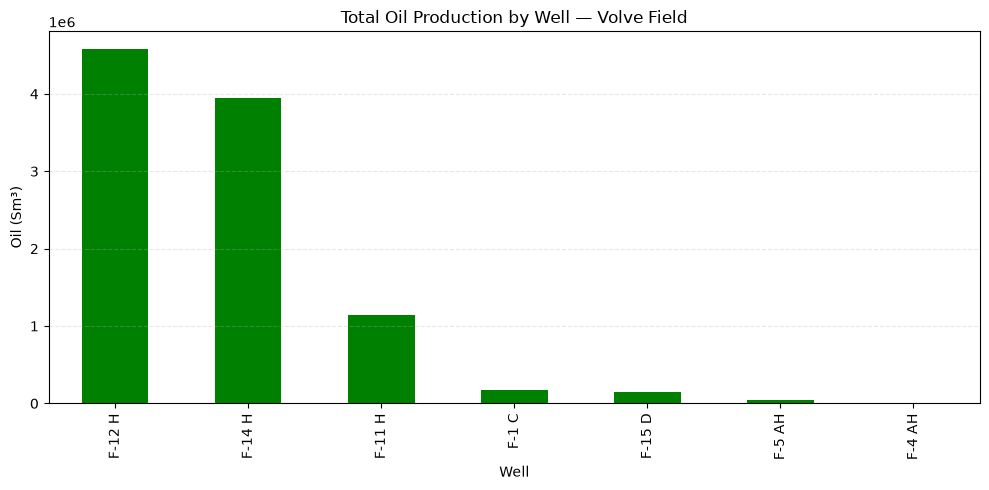

In [36]:
# Chart 1:Total Oil by Well

total_oil = df.groupby("Well")["Oil"].sum().sort_values(ascending=False) # group all rows by Well, then sum the Oil for each group
total_oil

total_oil.plot(kind="bar", figsize=(10, 5), color="green")
plt.title("Total Oil Production by Well — Volve Field")
plt.ylabel("Oil (Sm³)")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../images/total-oil-production-by-well.png", dpi=350)
plt.show()

In [37]:
# The charts oil rate, water cut, GOR uses rows with on-stream hours above zero.
# Rates need full days. Totals need every row.

producing = df[(df["Well Role"] == "Producer") & (df["On Stream Hours"] >=23)] 
# filter with two conditions: Well Role is Producer and On Stream Hours is almost full day
# filter for full day for a correct oil rate calculation.

producing.shape

#print(producing["Well"].nunique())   # how many
print(producing["Well"].unique())    # which ones

<StringArray>
['F-1 C', 'F-11 H', 'F-12 H', 'F-14 H', 'F-15 D', 'F-5 AH']
Length: 6, dtype: str


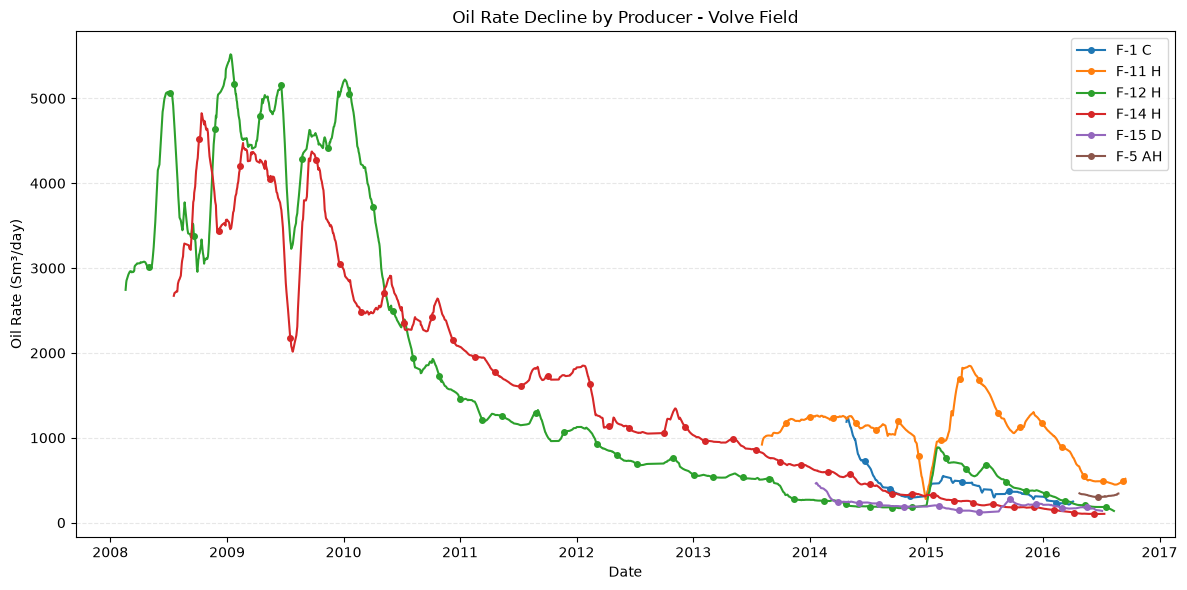

In [38]:
#Chart 2: Oil Rate Decline Over Time
# Oil Rate = Oil ÷ (Hours ÷ 24) # Divide a small oil volume by a tiny number of hours and you get a large, oil rate hence full day filtering.

plt.figure(figsize=(12, 6))

for well in producing["Well"].unique():
    one_well = producing[producing["Well"] == well].sort_values("Date")
    smooth = one_well.set_index("Date")["Oil Rate"].rolling(30, min_periods=5).mean() # 30-day rolling average to smooth noisy data keeps curve shape
    plt.plot(smooth.index, smooth.values, label=well, marker="o", markevery=60, markersize=4) # plot oil rate over time per well

plt.title("Oil Rate Decline by Producer - Volve Field")
plt.ylabel("Oil Rate (Sm³/day)")
plt.xlabel("Date")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../images/oil-rate-decline-by-producer.png", dpi=350)
plt.show()


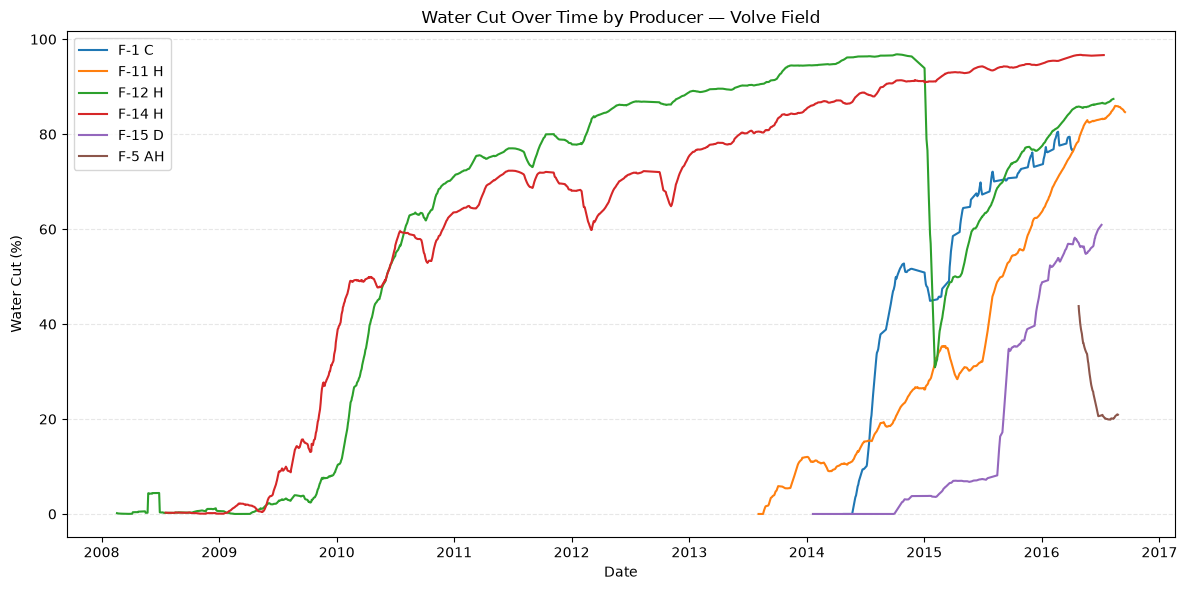

In [39]:
#Chart 3: Water Cut Over Time - fraction of liquid that is water-signals well is maturing

plt.figure(figsize=(12, 6))

for well in producing["Well"].unique():
    one_well = producing[producing["Well"] == well].sort_values("Date")
    smooth = one_well.set_index("Date")["Water Cut"].rolling(30, min_periods=5).mean()
    plt.plot(smooth.index, smooth.values * 100, label=well)     #Multiply by 100 to show as a percentage.

plt.title("Water Cut Over Time by Producer — Volve Field")
plt.ylabel("Water Cut (%)")
plt.xlabel("Date")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../images/watercut-over-time-by-producer.png", dpi=350)
plt.show()

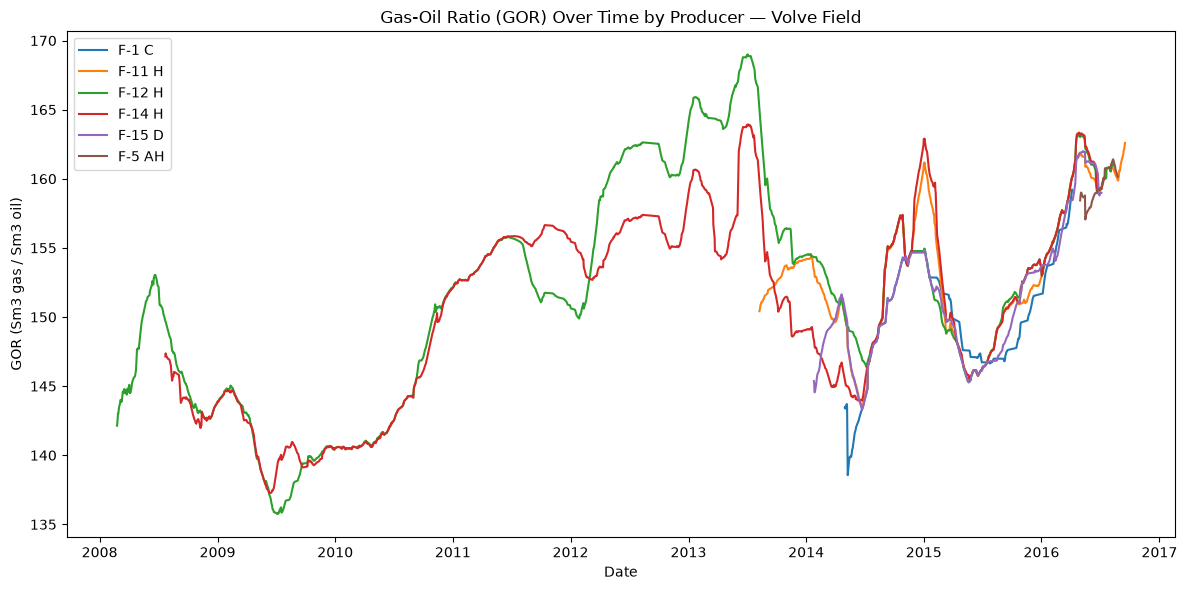

In [40]:
#Chart 4: Gas-Oil Ratio (GOR) Over Time
#GOR rises a sign the reservoir is losing energy. On Volve, water injection was used to hold pressure up, so a
#stable GOR is a sign the injection was working.

gor_data = producing[producing["GOR"] < 5000] # filter out extreme GOR values caused by near-zero oil days, since those are calculation artefacts, not real gas breakout.

plt.figure(figsize=(12, 6))

for well in gor_data["Well"].unique():
    one_well = gor_data[gor_data["Well"] == well].sort_values("Date")
    smooth = one_well.set_index("Date")["GOR"].rolling(60, min_periods=10).mean()
    plt.plot(smooth.index, smooth.values, label=well)

plt.title("Gas-Oil Ratio (GOR) Over Time by Producer — Volve Field")
plt.ylabel("GOR (Sm3 gas / Sm3 oil)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.savefig("../images/gas-oil-ratio-over-time-by-producer.png", dpi=350)
plt.show()

#What this shows:read together with water cut. A well with rising water cut
#but *stable* GOR means pressure held (injection worked) even as water arrived. A sharply rising GOR would mean pressure dropping and gas breaking out.

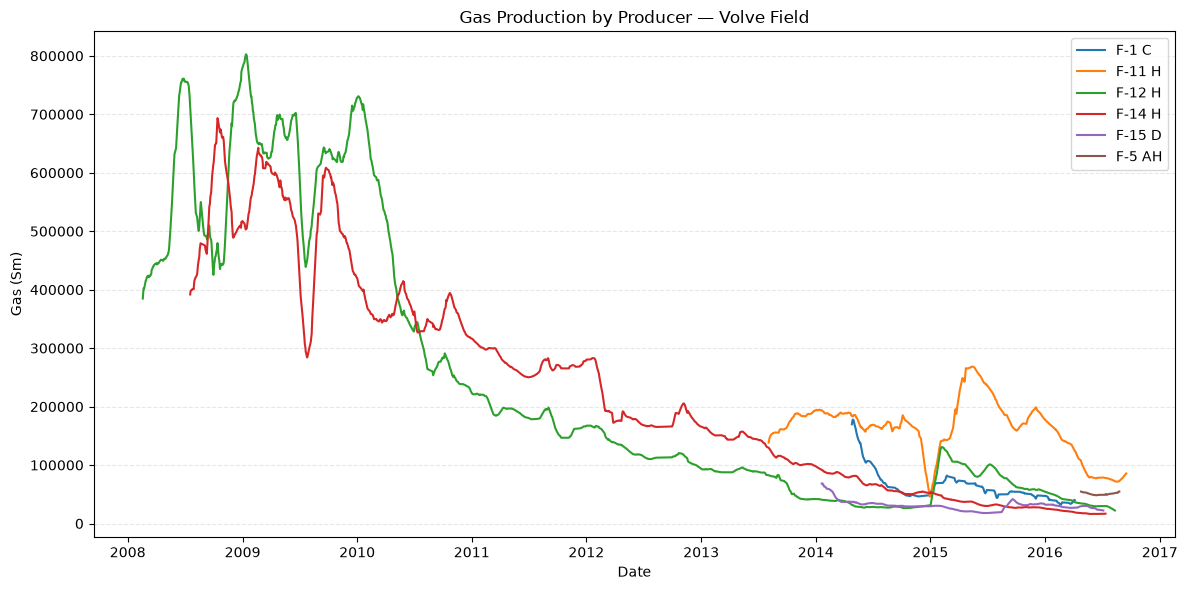

In [41]:
#Chart 5: Monthly gas production

plt.figure(figsize=(12, 6))

for well in producing["Well"].unique():
    one_well = producing[producing["Well"] == well].sort_values("Date")
    smooth = one_well.set_index("Date")["Gas"].rolling(30, min_periods=5).mean()
    plt.plot(smooth.index, smooth.values, label=well)

plt.title("Gas Production by Producer — Volve Field")
plt.ylabel("Gas (Sm)")
plt.xlabel("Date")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../images/gas-production-by-producer.png", dpi=350)
plt.show()


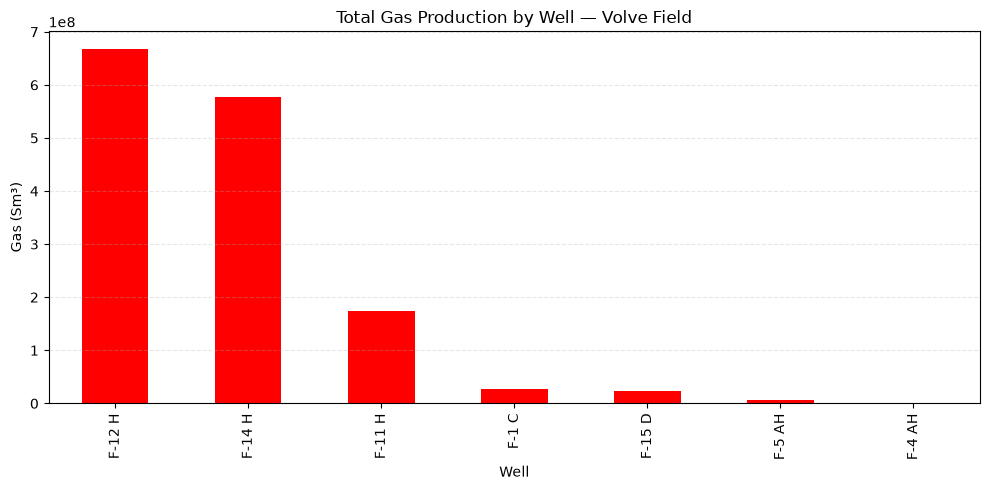

In [42]:
#Chart 6:Cumulative Gas by Well

total_gas = df.groupby("Well")["Gas"].sum().sort_values(ascending=False) # group all rows by Well, then sum the gas for each group
total_gas

total_gas.plot(kind="bar", figsize=(10, 5), color="red")
plt.title("Total Gas Production by Well — Volve Field")
plt.ylabel("Gas (Sm³)")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../images/total-gas-production-by-well.png", dpi=350)
plt.show()